## Visualizing Embedding transformer attentions

In [ ]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
config['masked_marks'] = []



eid = 'E116'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]
    checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"


    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]



    print(len(train_genes), len(val_genes))

    val_dataset = DeepBurstDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = DeepBurst(
        n_feats_p,
        d_emb,
        d_head,        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = model 
    datasets[fold] = val_dataset

Target genes: 15865
n_feats_p:7
11997 3868
Target genes: 15865
n_feats_p:7
11622 4243
Target genes: 15865
n_feats_p:7
11953 3912
Target genes: 15865
n_feats_p:7
12023 3842


In [10]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

# sns.set_palette("colorblind")


## Define heatmap

In [11]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0.2,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, 
                    cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
                    ax=axis,
                    vmin=vmin, 
                    vmax=vmax,
                    # cbar_kws={"orientation": "horizontal"}
                )
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        axis.set_xlabel(xlabel)
    
    if ylabel:
        axis.set_ylabel(ylabel)

    if xticklabels:
        axis.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels)

    g.set_title(title)


## Visualizing Embedding transformer attentions

### Load model and samples

### Embedding Transformer attentions visualized

### Analysis attention regions

In [12]:
def get_attention_weights(gene_id, dataset, model,binsize=500,dims=None):
    sample = dataset.get_sample(gene_id, add_bsz_dim=True)

    x = sample["promoter_feats"][binsize]
    mask = sample["promoter_pad_masks"][binsize]

    x, mask = model.generate_transformer_inputs(x, mask, binsize)
    attention_weights = np.squeeze(model.get_attention_weights(binsize,x,mask))
    if isinstance(dims,int):
        attention_weights = attention_weights[dims]
    else:
        attention_weights = np.sum(attention_weights, axis=0)
    return attention_weights

def extract_attention_regions(weights, chrom, center, strand, threshold=0.05, bin_size=500)->List[str]:
    if strand == '-':
        weights = np.flip(weights)

    def _distance_to_tss(location):
        return bin_size*(location-40)  # 第40个bin 以TSS 作为起点所在bin

    regions = []
    region = []
    for idx, weight in enumerate(weights):
        if weight > threshold:
            region.append(idx)
        else:
            if region:
                regions.append(region)
                region = []
    if region:
        regions.append(region)
    
    genomic_regions = []
    for region in regions:
        start = center + _distance_to_tss(region[0])
        end =  center + _distance_to_tss(region[-1]+1)
        genomic_regions.append(f"{chrom}:{start}-{end}")

    return genomic_regions

In [13]:
LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id').sort_values(by='bf_label_score',ascending=False)
data.head(20)



,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,start,strand
15761,ENSG00000186812,1,0.938567,1,1,0.978823,1,3,E116,chr18,32820996,+
14367,ENSG00000101266,1,0.816481,1,1,0.972444,1,3,E116,chr20,524434,-
15362,ENSG00000169967,1,0.967075,1,1,0.971891,1,3,E116,chr2,128145551,-
12757,ENSG00000131127,1,0.746563,1,0,0.968902,1,3,E116,chr4,331601,+
12695,ENSG00000115561,1,0.871753,1,1,0.964900,1,3,E116,chr2,86790566,-
12224,ENSG00000184432,1,0.953726,1,1,0.963988,1,3,E116,chr3,139108489,-
12822,ENSG00000124193,1,0.981187,1,0,0.963987,1,3,E116,chr20,42086534,+
14213,ENSG00000138750,1,0.940188,1,1,0.963254,1,3,E116,chr4,77069668,-
13142,ENSG00000119541,1,0.935721,1,1,0.961086,1,3,E116,chr18,61089709,-
15544,ENSG00000145332,1,0.864667,1,1,0.960923,1,3,E116,chr4,88141420,-


## Attention Case Analysis

### Low bs and high bf

100%|██████████| 1/1 [00:00<00:00, 14.70it/s]


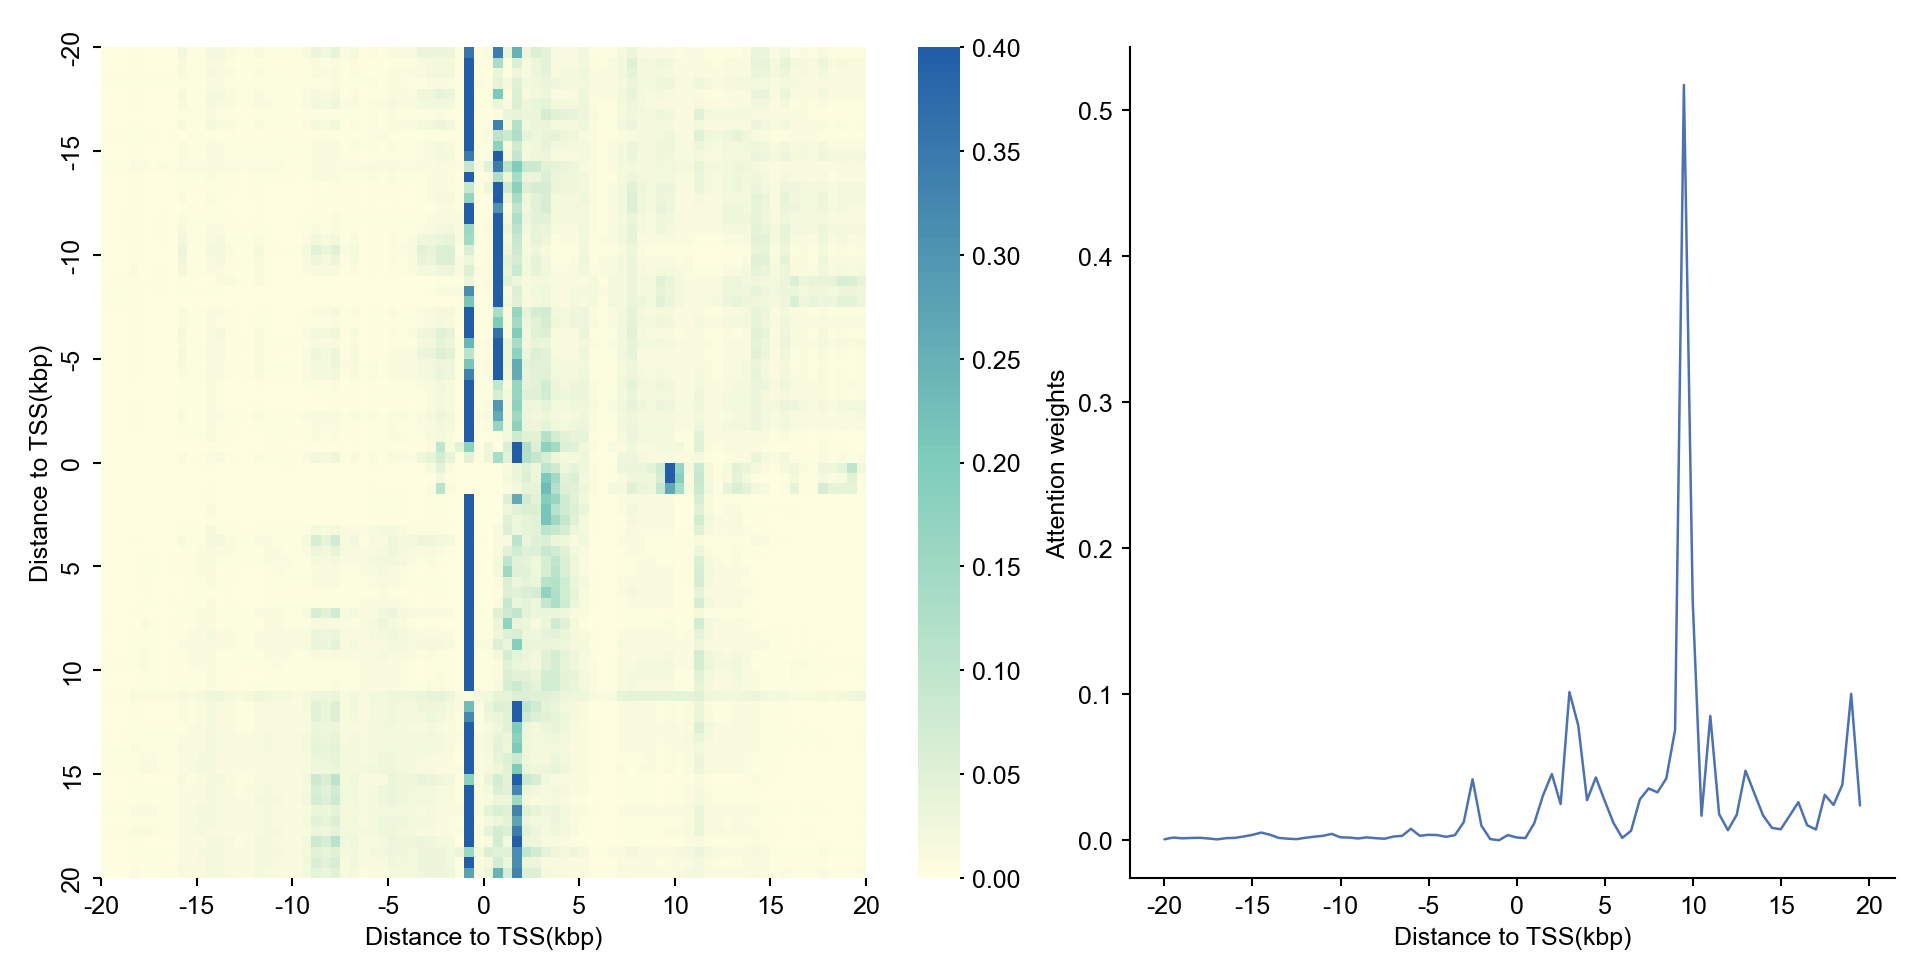

In [24]:
high_gene_ids = data[(data['bf_label_label']==1) & (data['gene_id']=='ENSG00000155660')]

# samples = [datasets[record['fold']].get_sample(record['gene_id'], add_bsz_dim=True) for record in high_gene_ids.to_records()]
dims = None
attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)
attention_distribution = attention_weights[40,:]

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
    vmin=0.0,
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()





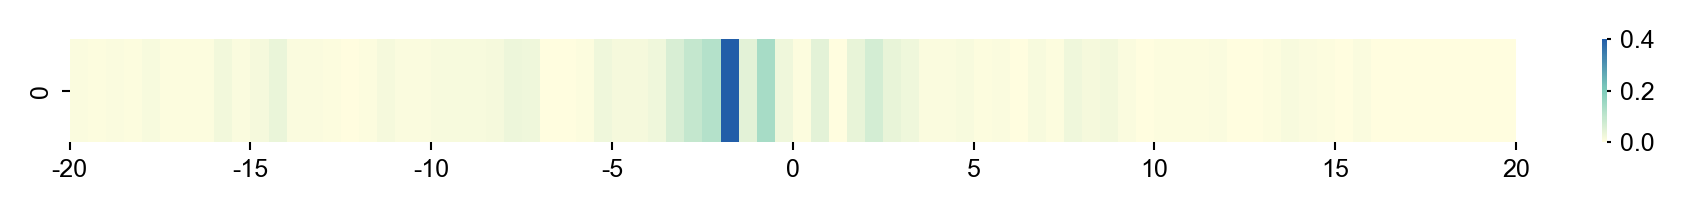

In [25]:
# sns.heatmap(np.flip(attention_weights[40:41,:]))

fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(14/2.54, 1.5/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
# yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    np.flip(attention_weights[39:40,:]),axis=ax,
    xticks=xticks,
    # yticks=yticks,
    xticklabels=xticklabels,
    # yticklabels=yticklabels,
    xlabel="",
    ylabel="",
    vmin=0.0,
)
plt.savefig('extra/figures/v7/Figure4F_attention0.eps', format='eps', bbox_inches='tight')



### Low bs and low bf

In [16]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['Low bs and low bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()


KeyError: 'labels_marks'

### High bs and low bf

100%|██████████| 2434/2434 [00:27<00:00, 87.03it/s]


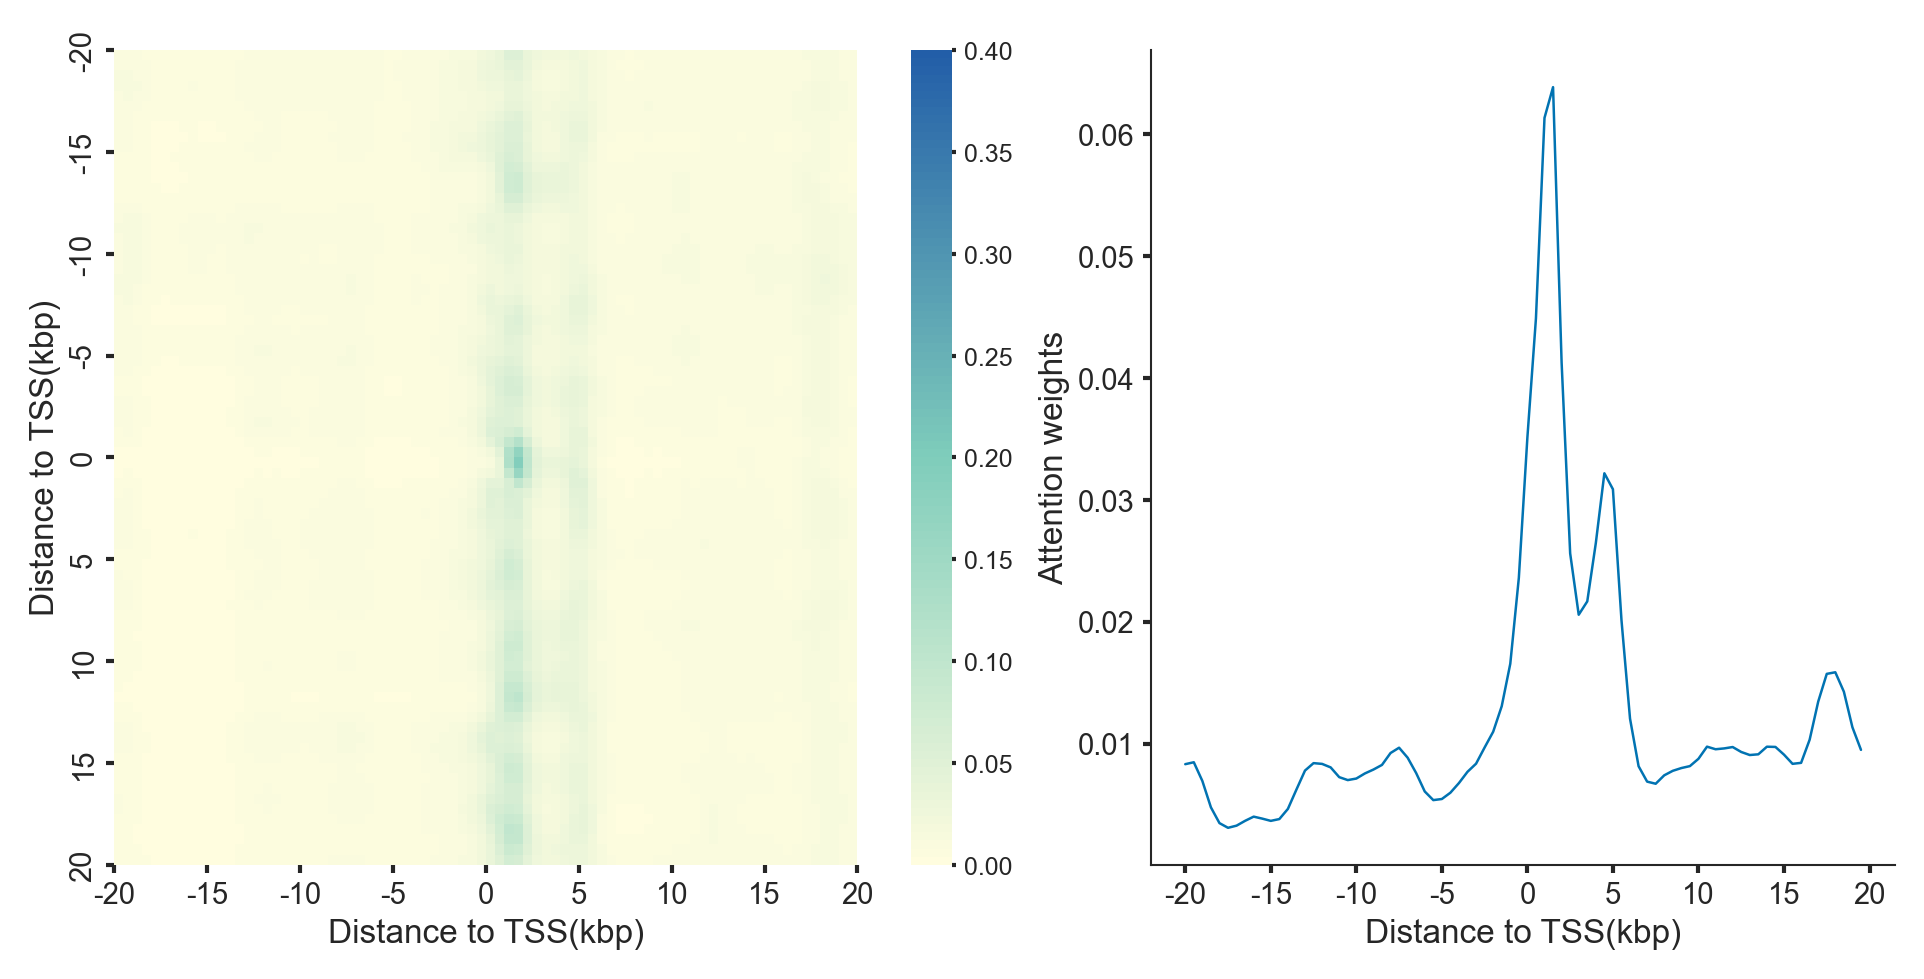

In [11]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['High bs and low bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()



### High bs and high bf

100%|██████████| 4715/4715 [00:54<00:00, 86.31it/s]


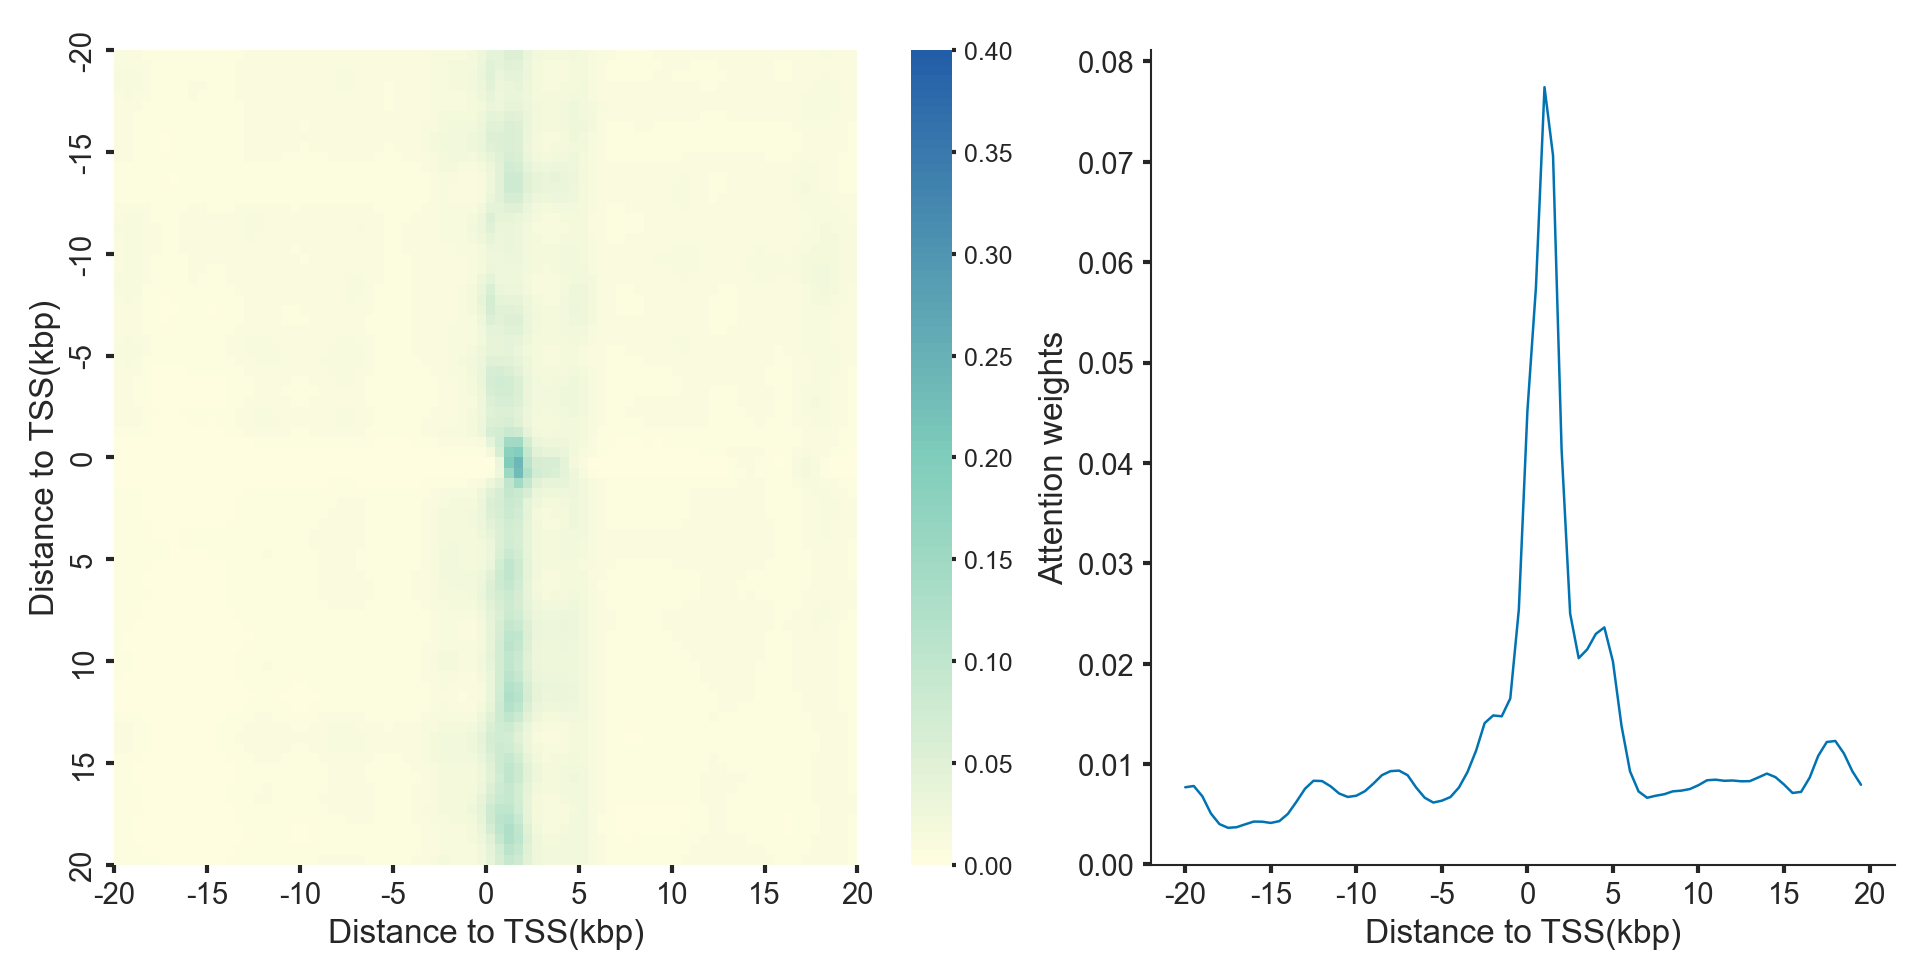

In [13]:
high_gene_ids = data[data['labels_marks']==LABEL_BIN_MAP['High bs and high bf']]

attention_weights = 0
gene_ids = high_gene_ids
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16/2.54, 8/2.54))

xticks = [i for i in range(0,81,10)]
yticks = [i for i in range(0,81,10)]
xticklabels = [int((i-40)/2) for i in range(0,81,10)]
yticklabels = [int((i-40)/2) for i in range(0,81,10)]
plot_heatmap(
    attention_weights,axis=ax[0],
    xticks=xticks,
    yticks=yticks,
    xticklabels=xticklabels,
    yticklabels=yticklabels,
    xlabel="Distance to TSS(kbp)",
    ylabel="Distance to TSS(kbp)",
)


sns.lineplot(attention_distribution,lw=0.6, label='Feature Importance',ax=ax[1])
ax[1].set_ylabel("Attention weights")
ax[1].set_xlabel("Distance to TSS(kbp)")
ax[1].legend().remove()
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xticklabels)

plt.show()




### ALL datasets(High and Low BF)

In [8]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and high bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and low bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)


  0%|          | 0/7154 [00:00<?, ?it/s]

100%|██████████| 7150/7150 [01:27<00:00, 82.02it/s]


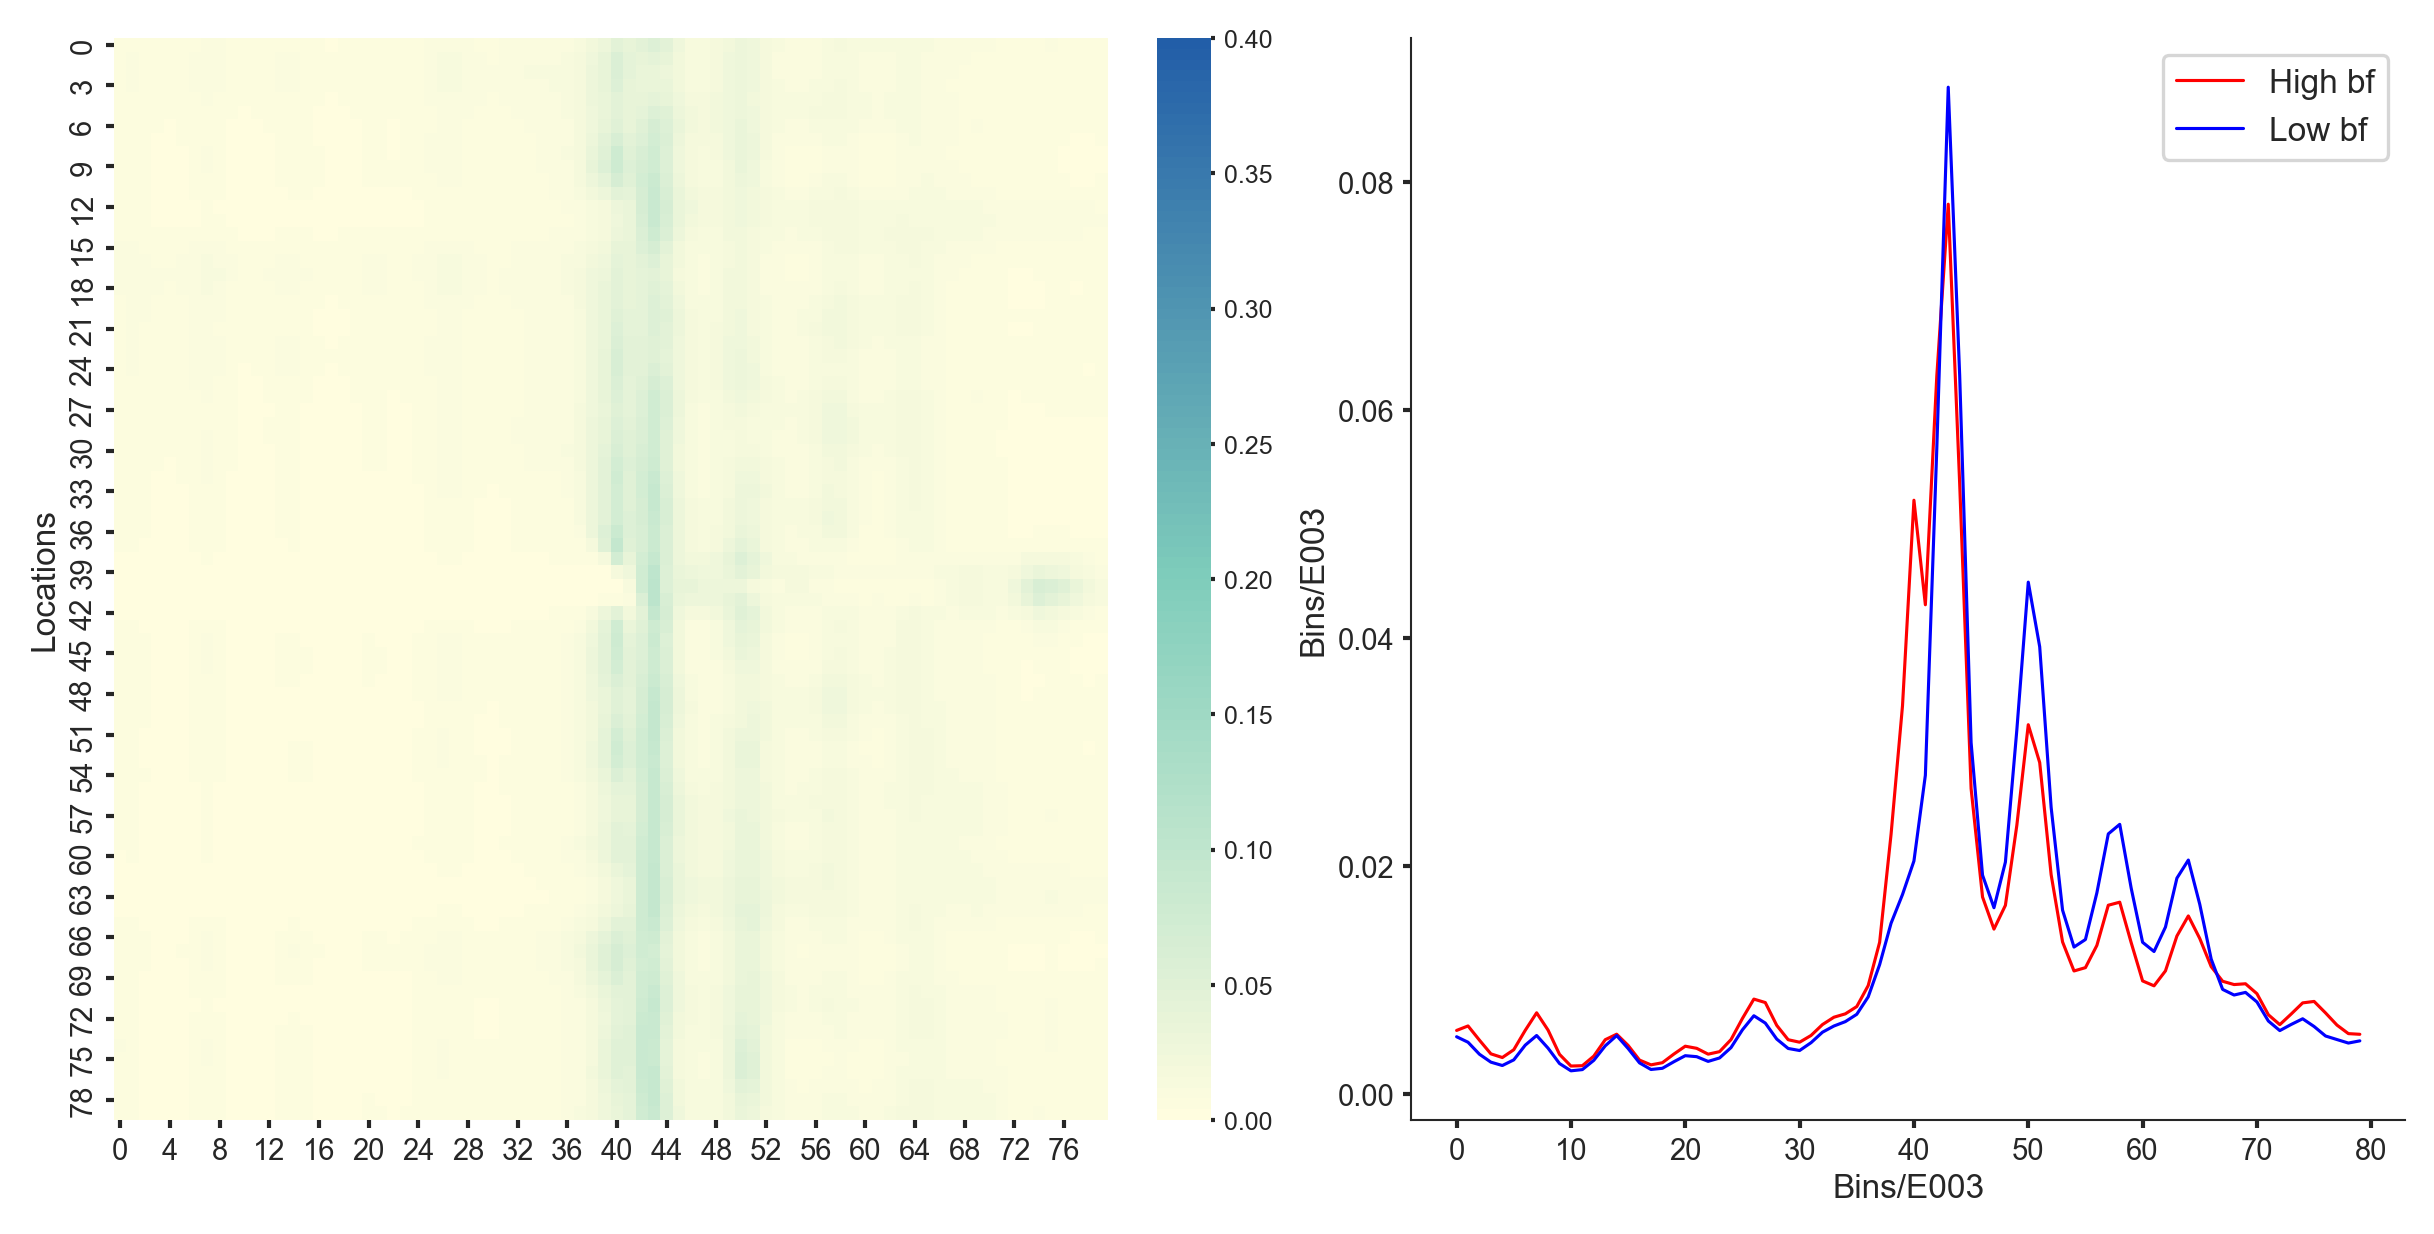

In [9]:

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bf',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bf',ax=ax[1],color='blue')
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()

### ALL datasets(High and Low BS)

  0%|          | 0/7149 [00:00<?, ?it/s]

100%|██████████| 9431/9431 [01:43<00:00, 90.76it/s]


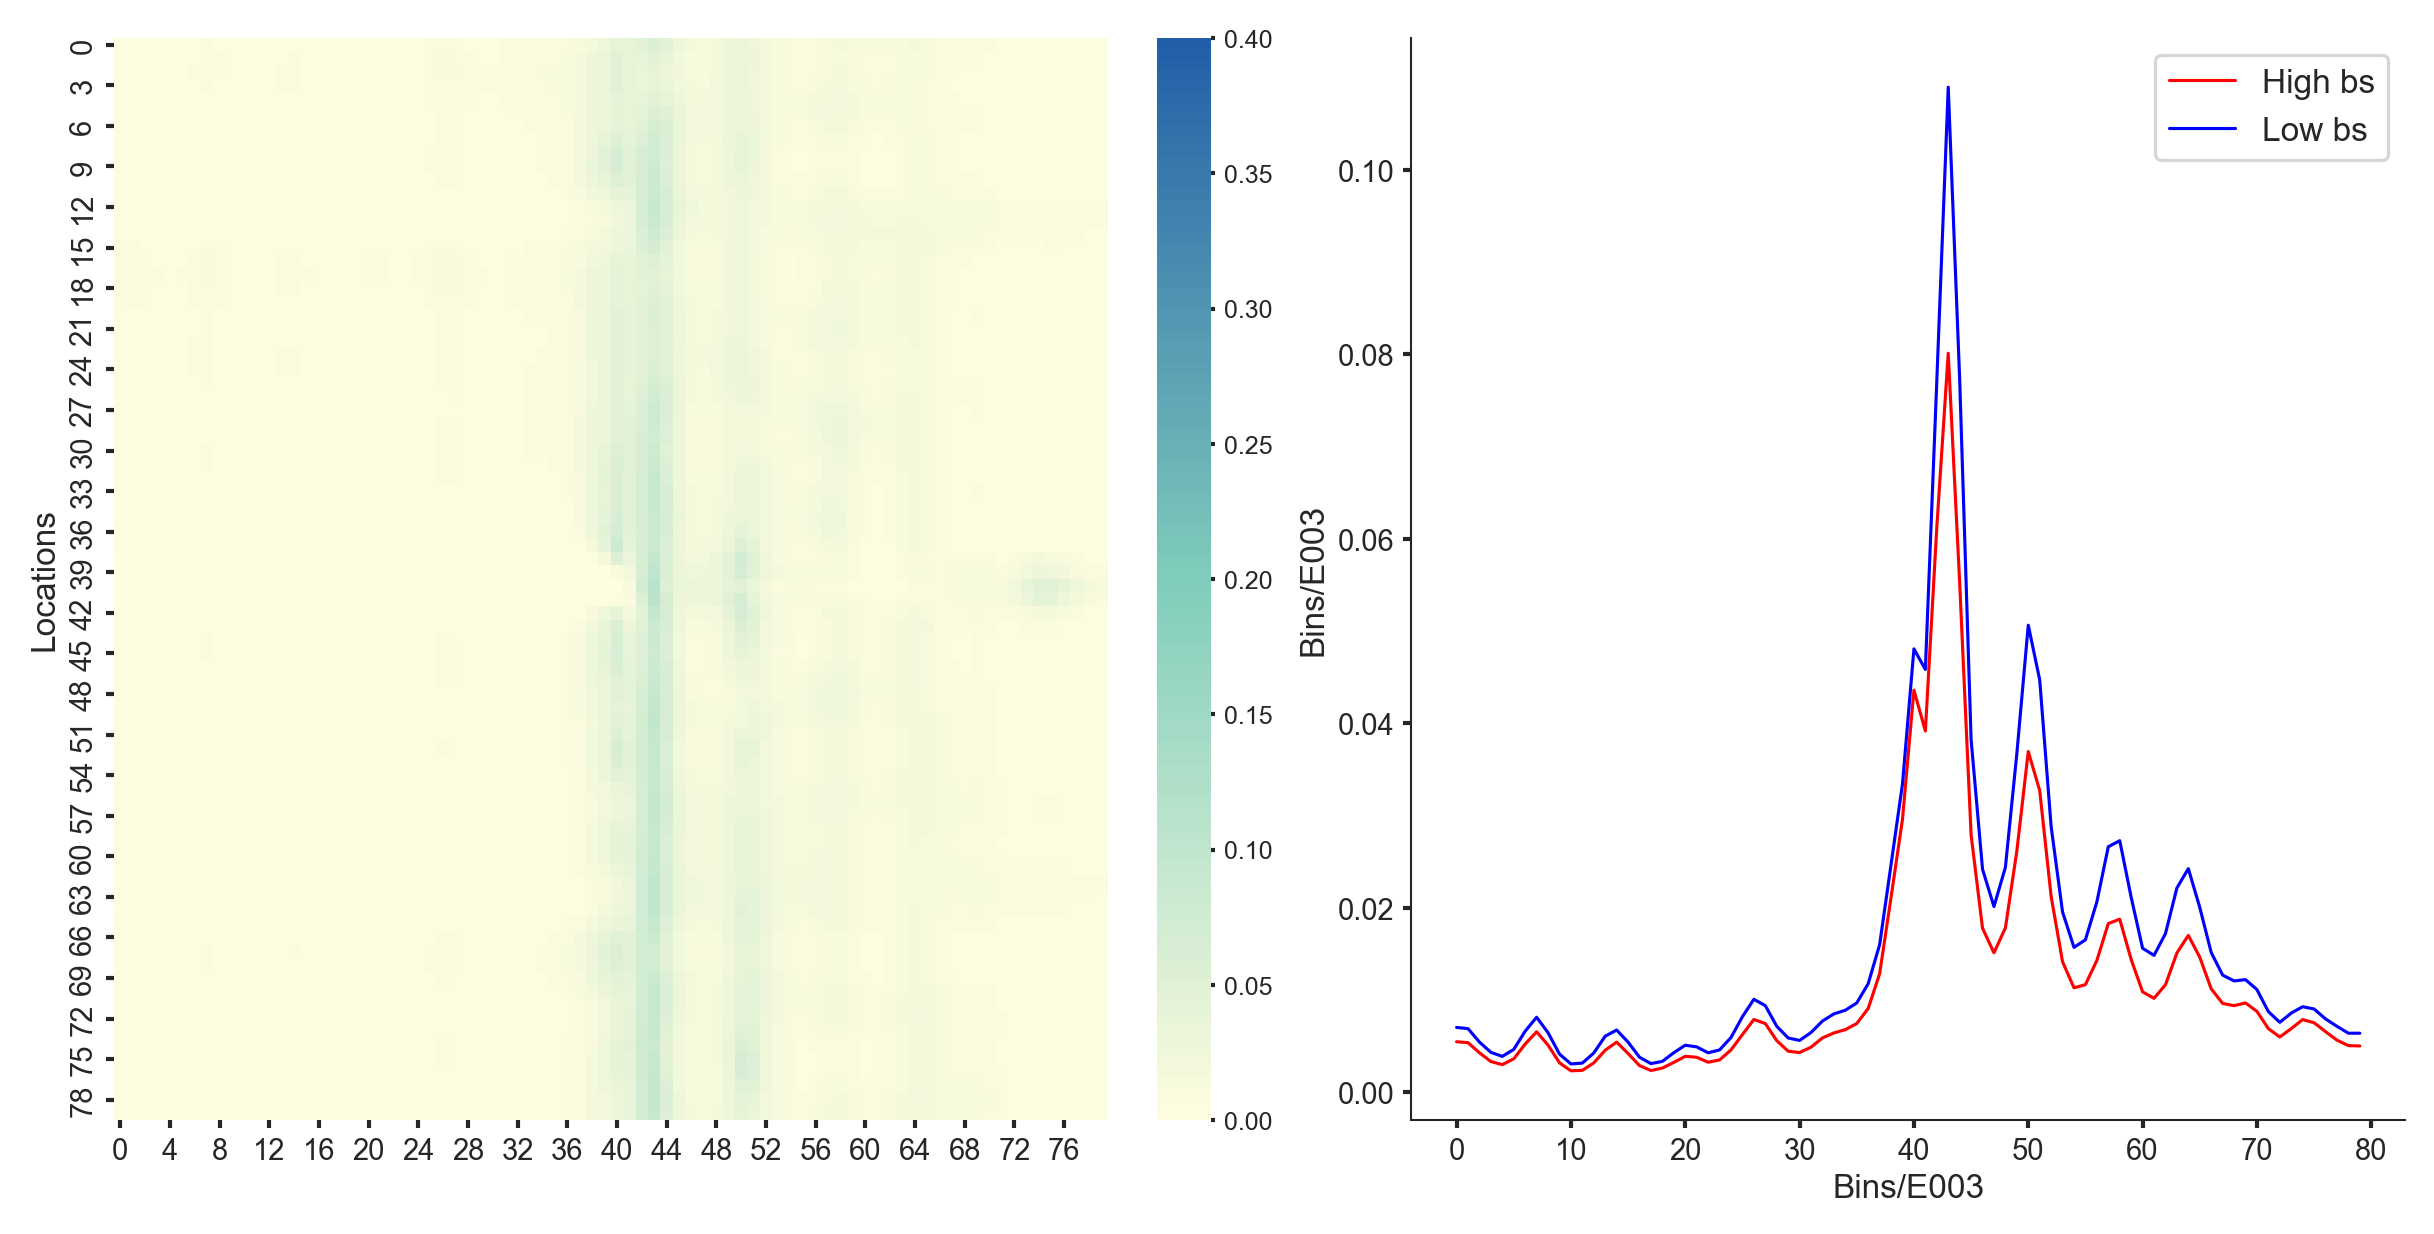

In [11]:
high_gene_ids = data[(data['labels_marks'].isin([LABEL_BIN_MAP['High bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

high_attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    high_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

high_attention_weights = high_attention_weights/len(high_gene_ids)

high_attention_distribution = np.mean(high_attention_weights, axis=0)


low_gene_ids =  data[(data['labels_marks'].isin([LABEL_BIN_MAP['Low bs and low bf'],LABEL_BIN_MAP['High bs and high bf']])) ]

low_attention_weights = 0
for record in tqdm(low_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    low_attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

low_attention_weights = low_attention_weights/len(high_gene_ids)

low_attention_distribution = np.mean(low_attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(high_attention_weights,axis=ax[0])
sns.lineplot(high_attention_distribution,label='High bs',ax=ax[1],color='red')
sns.lineplot(low_attention_distribution,label='Low bs',ax=ax[1],color='blue')
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()


### ALL datasets

100%|██████████| 14304/14304 [02:42<00:00, 88.17it/s]


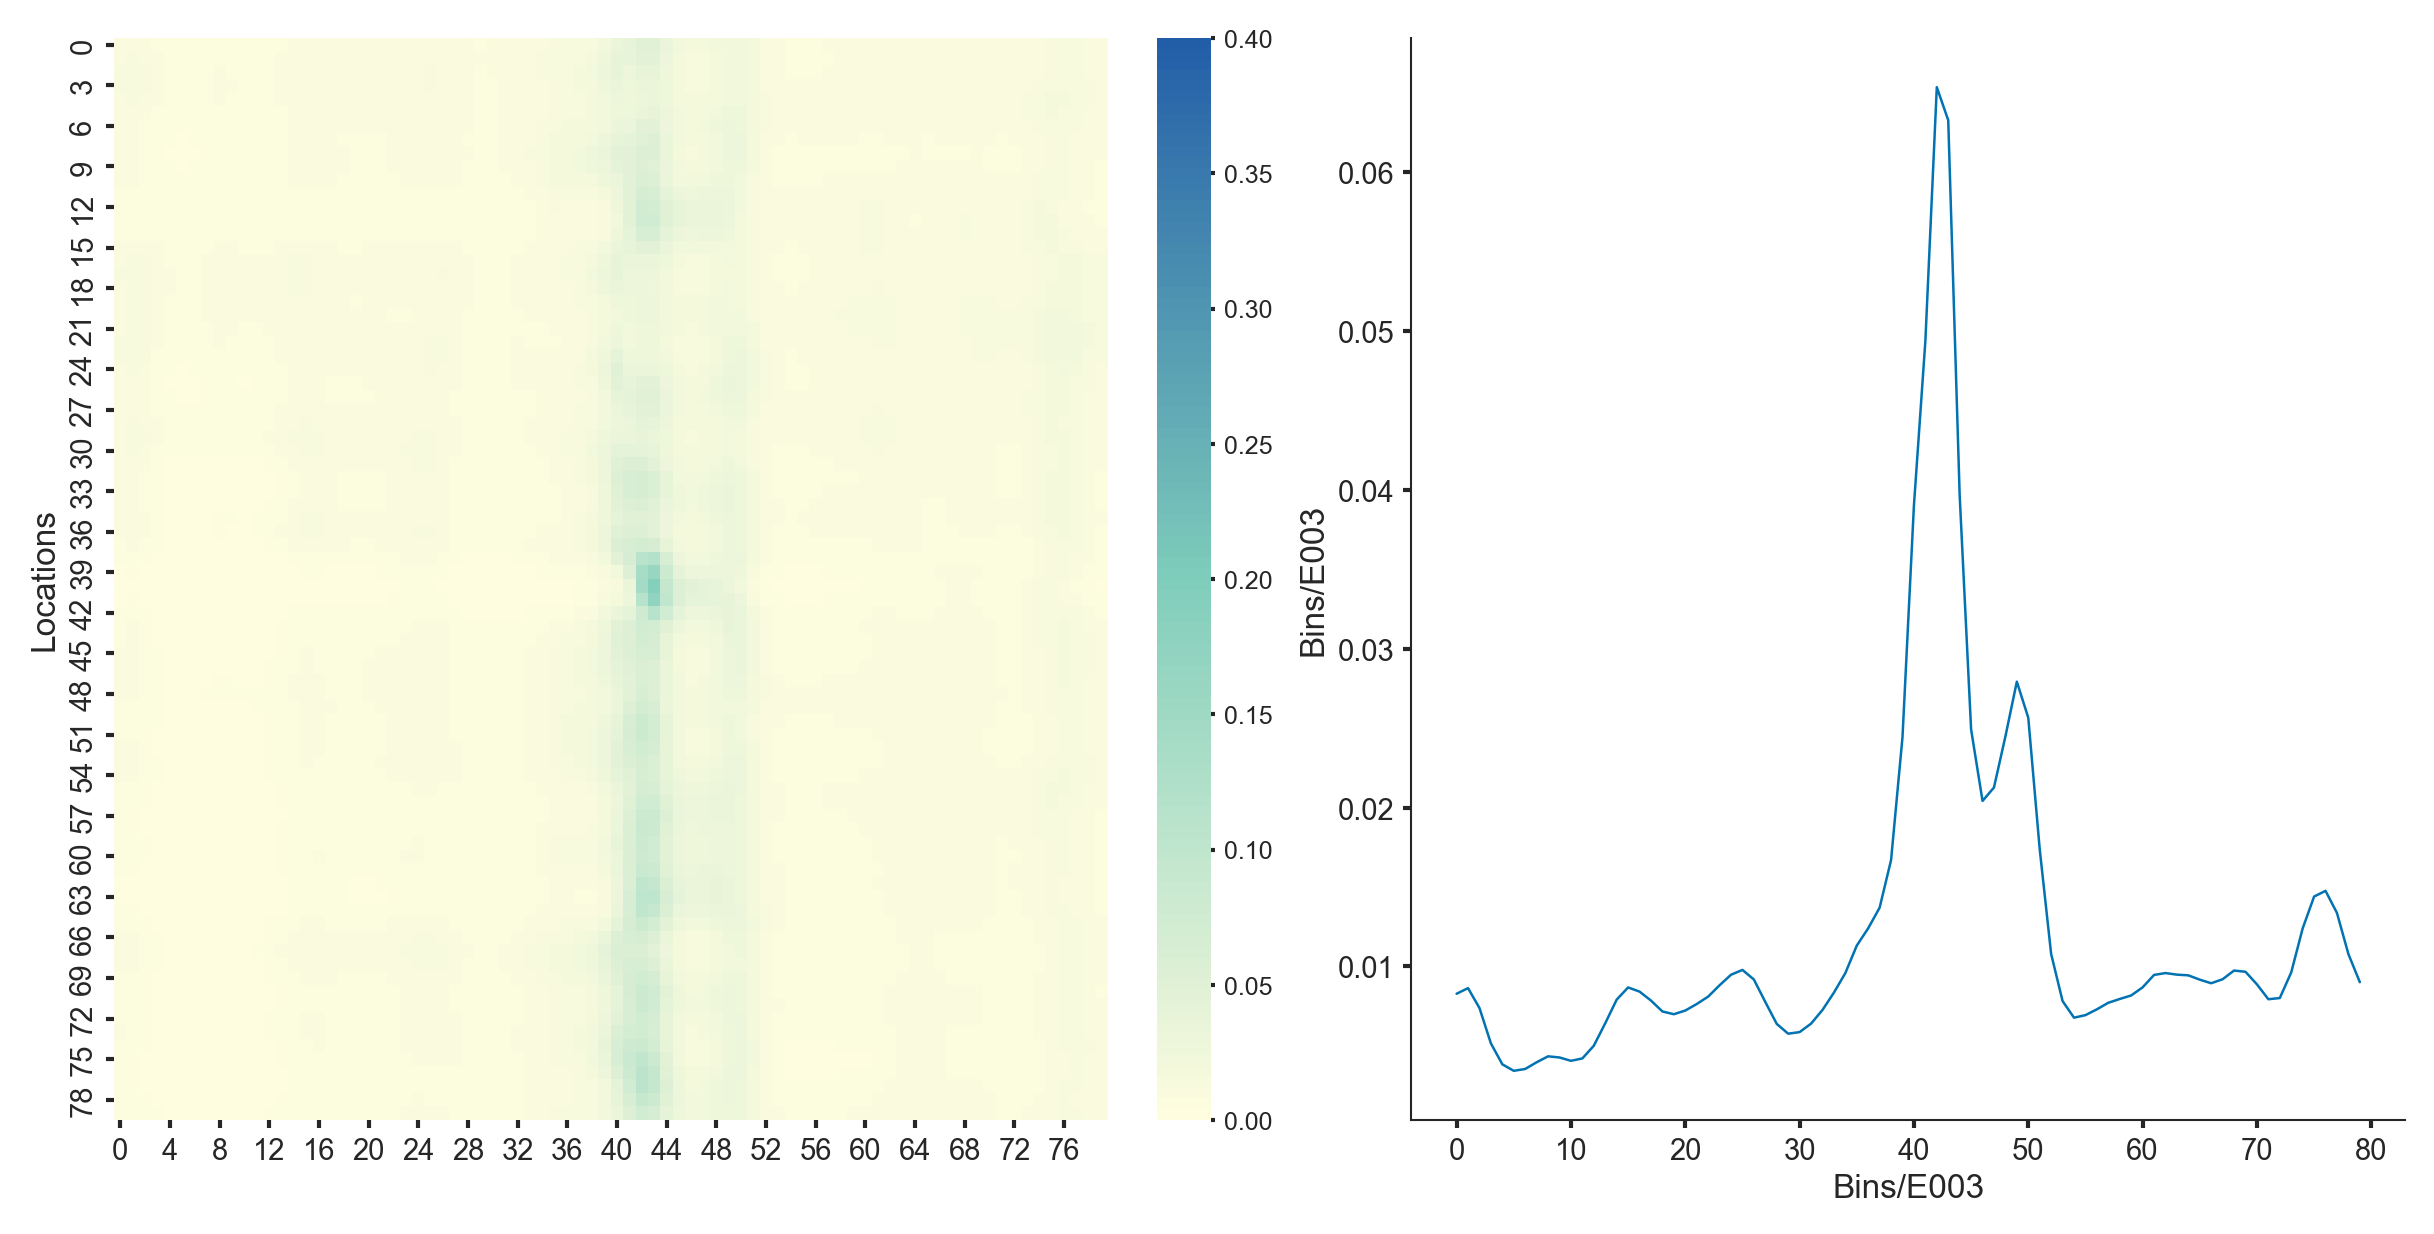

In [10]:
high_gene_ids = data

attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(high_gene_ids)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(attention_weights,axis=ax[0])
plt.plot(attention_distribution,lw=0.6, label='Feature Importance')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()




